# Partitioning Analysis — 3-axis persona (CircuitNet-N28)

Companion to `partitioning_analysis.ipynb`. Same two "main" strategies
(hierarchical deterministic and data-driven k-prototypes), but the persona
axis is expanded from `(design × clock)` to `(design × clock × utilization)`.

| id | strategy | client count |
| -- | -------- | ------------ |
| P1c | Hierarchical deterministic: `design × clock_bin × util_bin` | 6 × 2 × 2 = **24** |
| P3c | k-prototypes on weighted mixed-type features, `k = 24` | 24 |

Both `clock_ns` and `utilization` are already in the P3 weight schema
(w = 1.5 each, via `log_frequency` and `utilization`), so bumping k from 12
to 24 asks k-prototypes to split each of the 12 (design × clock-tier) cells
roughly along the utilization axis — the same cross-product P1c constructs
deterministically. Comparing them via ARI/NMI + confusion matrix is the
cleanest test of whether the natural metadata clusters match the hand-drawn
3-axis personas.

# Imports

In [22]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
from scipy.spatial.distance import jensenshannon
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
    davies_bouldin_score,
)

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.titlesize': 11,
    'axes.grid': True,
    'grid.color': 'white',
    'grid.linewidth': 0.8,
    'axes.facecolor': '#f5f5f5',
    'figure.facecolor': 'white',
})

sys.path.insert(0, os.path.abspath('.'))
from partitioning import (
    HierarchicalPersonaPartitioner,
    KPrototypesPartitioner,
)

FEATURE_DIR = '../routability_ir_drop_prediction/training_set_N28/DRC/feature'
OUT_DIR = './partition_outputs'
os.makedirs(OUT_DIR, exist_ok=True)
SILHOUETTE_SAMPLE_SIZE = 2000  # keep silhouette memory ~O(sample^2)
print('Imports OK.')

Imports OK.


# Load metadata + derive features

Same parser and derivations as the main partitioning notebook so both P1c
(hierarchical) and P3c (k-prototypes) run on identical inputs.

In [23]:
def parse_sample_name(filename: str) -> dict:
    basename = filename.replace('.npy', '')
    parts = basename.split('-')
    if parts[0].isdigit():
        parts = parts[1:]
    if len(parts) < 7:
        raise ValueError(f'Cannot parse: {filename}')
    for expected, token in zip(['c','u','m','p','f'], parts[-5:]):
        if not token.startswith(expected):
            raise ValueError(f'Bad token {token} in {filename}')
    c, u, m, p, f = parts[-5:]
    return {
        'design_name':      '-'.join(parts[:-6]),
        'macro_count':      parts[-6],
        'clock_ns':         float(c[1:]),
        'utilization':      float(u[1:]),
        'macro_placement':  m[1:],
        'power_mesh':       p[1:],
        'filler_insertion': f[1:],
        'filename':         filename,
    }

files = sorted(f for f in os.listdir(FEATURE_DIR) if f.endswith('.npy'))
df_meta = pd.DataFrame([parse_sample_name(f) for f in files])
df_meta.loc[~df_meta['macro_placement'].isin(['1','2','3','4']), 'macro_placement'] = '1'

SIZE_MAP = {
    'zero-riscy-a': 'small', 'zero-riscy-b': 'small',
    'RISCY-a':      'small', 'RISCY-b':      'small',
    'RISCY-FPU-a':  'small', 'RISCY-FPU-b':  'small',
    'OpenC910-1':   'medium', 'Vortex-small': 'medium',
    'Vortex-large': 'large',  'NVDLA-small':  'large', 'NVDLA-large': 'large',
}
FILLER_MAP = {'0': 'after_routing', '1': 'after_placement'}

df_meta['size_class']    = df_meta['design_name'].map(SIZE_MAP).fillna('small')
df_meta['log_frequency'] = np.log10(1000.0 / df_meta['clock_ns'].astype(float))
df_meta['filler']        = df_meta['filler_insertion'].map(FILLER_MAP).fillna(df_meta['filler_insertion'])
df_meta['aspect_ratio']  = 1.0

print(f'Samples: {len(df_meta)}   Designs: {df_meta["design_name"].nunique()}')
print(f'clock_ns    unique: {sorted(df_meta["clock_ns"].unique().tolist())}')
print(f'utilization unique: {sorted(df_meta["utilization"].unique().tolist())}')

Samples: 10242   Designs: 6
clock_ns    unique: [2.0, 5.0, 20.0]
utilization unique: [0.7, 0.75, 0.8, 0.85, 0.9]


# Config

`N_CLIENTS = 6 × 2 × 2 = 24`:

- 6 unique `design_name` values (RISCY-a/b, RISCY-FPU-a/b, zero-riscy-a/b),
- 2 quantile bins of `clock_ns` (splits the {2, 5, 20} ns values into
  low-period / high-period ≈ high-freq / low-freq),
- 2 quantile bins of `utilization` (splits the {0.70, 0.75, 0.80, 0.85, 0.90}
  values into low-density / high-density).

24 clients on ~10k samples gives ~425 samples/client on average — still
usable for the DRC CNN, but note that some cells (e.g. rare
clock/util pairs) will be smaller.

In [24]:
N_DESIGNS       = df_meta['design_name'].nunique()
N_CLOCK_BINS    = 2
N_UTIL_BINS     = 2
N_CLIENTS       = N_DESIGNS * N_CLOCK_BINS * N_UTIL_BINS
SEED            = 42
print(f'N_CLIENTS = {N_DESIGNS} designs x {N_CLOCK_BINS} clock bins x {N_UTIL_BINS} util bins = {N_CLIENTS}')

N_CLIENTS = 6 designs x 2 clock bins x 2 util bins = 24


# Scoring helpers

Identical to `partitioning_analysis.ipynb`. Repeated here so this notebook is
self-contained.

In [25]:
FACTOR_COLS = [
    'design_name', 'clock_ns', 'utilization',
    'macro_placement', 'power_mesh', 'filler_insertion',
]

global_props = {c: df_meta[c].astype(str).value_counts(normalize=True) for c in FACTOR_COLS}


def per_client_composition(parts, col):
    cols = []
    for i, p in enumerate(parts):
        vc = p[col].astype(str).value_counts(normalize=True)
        vc.name = f'c{i}'
        cols.append(vc)
    return pd.concat(cols, axis=1).fillna(0.0).sort_index()


def js_divergence_to_global(parts, col, global_dist):
    all_levels = sorted(set(global_dist.index) | set().union(
        *[set(p[col].astype(str).unique()) for p in parts]
    ))
    g = global_dist.reindex(all_levels).fillna(0.0).to_numpy()
    g = g / max(g.sum(), 1e-12)
    out = []
    for p in parts:
        vc = p[col].astype(str).value_counts(normalize=True)
        v = vc.reindex(all_levels).fillna(0.0).to_numpy()
        if v.sum() == 0:
            out.append(np.nan)
        else:
            v = v / v.sum()
            out.append(float(jensenshannon(v, g, base=2) ** 2))
    return out


def summarize(parts, name, factor_cols=FACTOR_COLS):
    sizes = [len(p) for p in parts]
    print(f'\n=== {name} ===')
    print(f'  clients            : {len(parts)}')
    print(f'  size min/median/max: {min(sizes)} / {int(np.median(sizes))} / {max(sizes)}')
    imb = max(sizes) / max(min(sizes), 1)
    print(f'  size imbalance     : max/min = {imb:.2f}x')
    js = {}
    for col in factor_cols:
        js[col] = float(np.nanmean(js_divergence_to_global(parts, col, global_props[col])))
    for col, v in js.items():
        print(f'  mean JS({col:20s}) = {v:.3f}')
    return {'name': name, 'sizes': sizes, 'imbalance': imb, 'js_mean': js}


def plot_partition_composition(parts, name, cols=('design_name','clock_ns','utilization')):
    fig, axes = plt.subplots(1, len(cols), figsize=(6 * len(cols), 6))
    if len(cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        comp = per_client_composition(parts, col)
        levels = comp.index.tolist()
        n_clients = comp.shape[1]
        cmap = mcm.get_cmap('tab20', max(len(levels), 3))
        bottom = np.zeros(n_clients)
        for j, lvl in enumerate(levels):
            h = comp.iloc[j].to_numpy()
            ax.bar(range(n_clients), h, bottom=bottom,
                   color=cmap(j % cmap.N), label=str(lvl),
                   alpha=0.9, edgecolor='white', linewidth=0.5)
            bottom += h
        ax.set_xticks(range(n_clients))
        ax.set_xticklabels([f'c{i}' for i in range(n_clients)], rotation=60, ha='right', fontsize=7)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel('within-client proportion')
        ax.set_title(f'{name}: P({col} | client)')
        if len(levels) <= 14:
            ax.legend(fontsize=7, loc='center left', bbox_to_anchor=(1.0, 0.5))
    plt.tight_layout()
    plt.show()


def sample_to_client(parts, key='filename'):
    m = {}
    for i, p in enumerate(parts):
        for k in p[key]:
            m[k] = i
    return m


def align_labels(reference_parts, other_parts, key='filename'):
    r = sample_to_client(reference_parts, key)
    o = sample_to_client(other_parts, key)
    keys = [k for k in r if k in o]
    return (np.array([r[k] for k in keys]),
            np.array([o[k] for k in keys]))


results = {}

# P1c — Hierarchical deterministic (design × clock_bin × util_bin)

Uses the multi-axis form of `HierarchicalPersonaPartitioner`:

```python
HierarchicalPersonaPartitioner(
    n_partitions=24,
    design_col='design_name',
    persona_col=['clock_ns', 'utilization'],
    n_persona_bins=[2, 2],
)
```

Cell key format: `<design>|clock_ns<i>|utilization<j>`.

Because both persona axes use quantile bins and the underlying design-space
sweep is fully factorial (every design × every clock × every utilization),
the 24 cells should end up roughly evenly populated.

P1c cells (design|clock_bin|util_bin, sample count, clock/util unique):
  c 0  RISCY-FPU-a|clock_ns0|utilization0            n=  936  clock=[2.0, 5.0]  util=[0.7, 0.75, 0.8]
  c 1  RISCY-FPU-a|clock_ns0|utilization1            n=  434  clock=[2.0, 5.0]  util=[0.85, 0.9]
  c 2  RISCY-FPU-a|clock_ns1|utilization0            n=  431  clock=[20.0]  util=[0.7, 0.75, 0.8]
  c 3  RISCY-FPU-a|clock_ns1|utilization1            n=  168  clock=[20.0]  util=[0.85, 0.9]
  c 4  RISCY-FPU-b|clock_ns0|utilization0            n=  604  clock=[2.0, 5.0]  util=[0.7, 0.75, 0.8]
  c 5  RISCY-FPU-b|clock_ns0|utilization1            n=  426  clock=[2.0, 5.0]  util=[0.85, 0.9]
  c 6  RISCY-FPU-b|clock_ns1|utilization0            n=  152  clock=[20.0]  util=[0.7, 0.75, 0.8]
  c 7  RISCY-FPU-b|clock_ns1|utilization1            n=   66  clock=[20.0]  util=[0.85, 0.9]
  c 8  RISCY-a|clock_ns0|utilization0                n=  981  clock=[2.0, 5.0]  util=[0.7, 0.75, 0.8]
  c 9  RISCY-a|clock_ns0|utilization1         

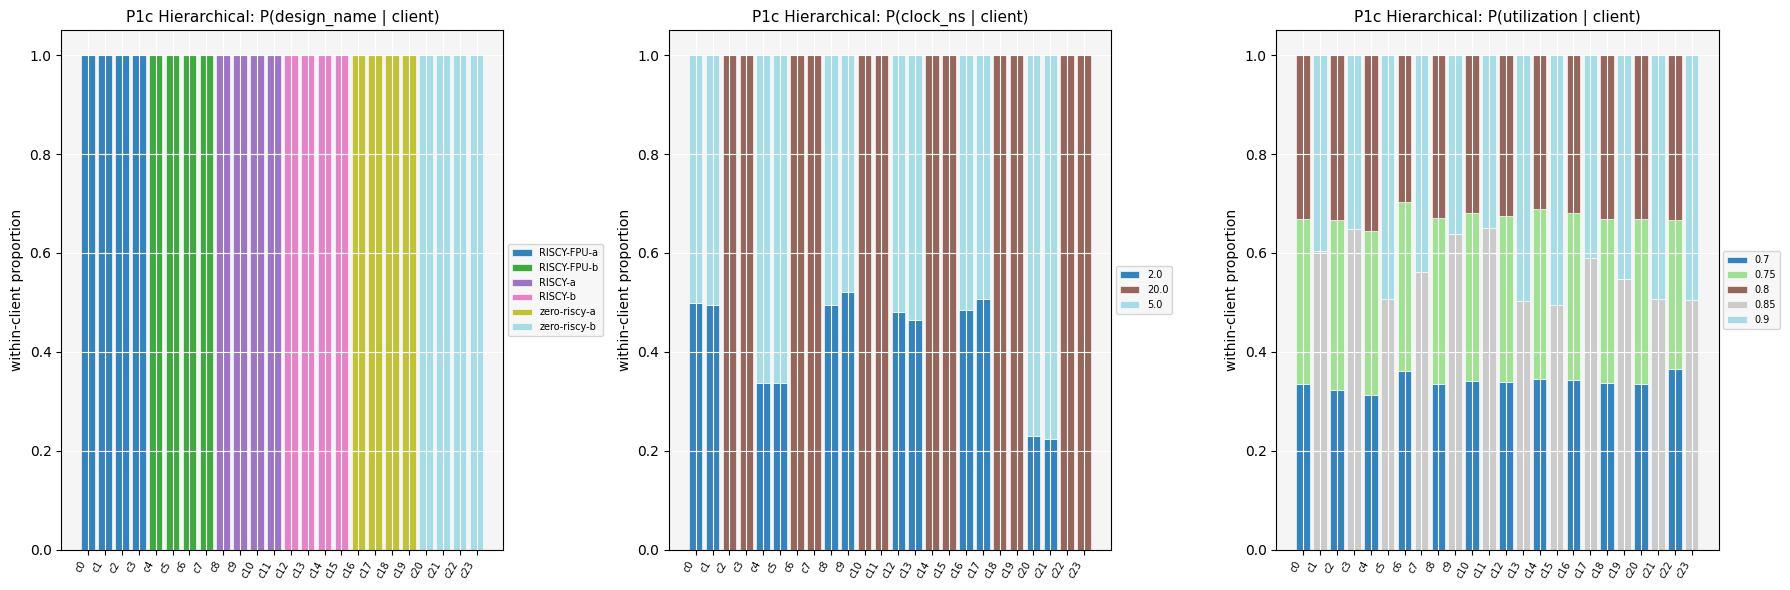

In [26]:
p1c = HierarchicalPersonaPartitioner(
    n_partitions=N_CLIENTS,
    design_col='design_name',
    persona_col=['clock_ns', 'utilization'],
    n_persona_bins=[N_CLOCK_BINS, N_UTIL_BINS],
    bin_method='quantile',
    seed=SEED,
).partition(df_meta)

print('P1c cells (design|clock_bin|util_bin, sample count, clock/util unique):')
for i, part in enumerate(p1c):
    print(f'  c{i:2d}  {part["_client_cell"].iloc[0]:45s} n={len(part):5d}  '
          f'clock={sorted(part["clock_ns"].unique())}  '
          f'util={sorted(part["utilization"].unique())}')

results['P1c_hier3'] = summarize(p1c, 'P1c Hierarchical (design x clock x util)')
plot_partition_composition(p1c, 'P1c Hierarchical',
                           cols=('design_name','clock_ns','utilization'))

# k sweep for P3c

Same three-metric diagnostic as in `kprototypes_analysis.ipynb`, applied to
the P3c encoded matrix so we can validate the `k = N_CLIENTS = 24` choice
against the data:

- **Silhouette** (higher = better; subsample of 2000 rows so we don't build
  a 10k×10k distance matrix). Peaks at the "most-separated" k.
- **Inertia** (lower = better). Look for the elbow.
- **Davies-Bouldin** (lower = better). Complements silhouette; when the
  three curves agree the choice is stable.

The sweep covers `k ∈ [2, 30]` so both the 2-axis (k=12) and 3-axis (k=24)
candidates land inside the range with headroom on either side. `k=24` is
highlighted; if a different k dominates the metrics you can either accept
the recommendation or defend the 24-client choice on interpretability grounds
(the deterministic 3-axis grid).

Encoded matrix shape: (10242, 22)
Dropped features (missing / constant on N28): [('size_class', 'constant'), ('aspect_ratio', 'constant')]


    silhouette     inertia     DBI
k                                 
2       0.1068  17861.8990  2.2103
3       0.1589  15933.4375  2.1361
4       0.2075  14091.4627  2.0218
5       0.2457  12513.2022  1.8493
6       0.2764  11328.6841  1.4819
7       0.2400  10900.5338  1.6119
8       0.2256  10490.5449  1.7046
9       0.2164  10088.6503  1.7761
10      0.1922   9883.2152  1.9839
11      0.1985   9536.3181  1.9113
12      0.1921   9341.7727  1.9724
13      0.1858   9143.3412  2.0251
14      0.1612   9039.4146  2.2137
15      0.1593   8826.7883  2.2101
16      0.1432   8688.8588  2.3287
17      0.1448   8557.4484  2.2471
18      0.1442   8442.6787  2.2343
19      0.1519   8299.8113  2.1241
20      0.1507   8213.4342  2.0944
21      0.1554   8095.0556  2.1324
22      0.1553   8014.6490  2.0679
23      0.1530   7925.9353  2.0479
24      0.1492   7801.4808  2.0177
25      0.1548   7763.0764  2.1106
26      0.1411   7673.2682  2.0828
27      0.1586   7548.3146  2.0277
28      0.1717   740

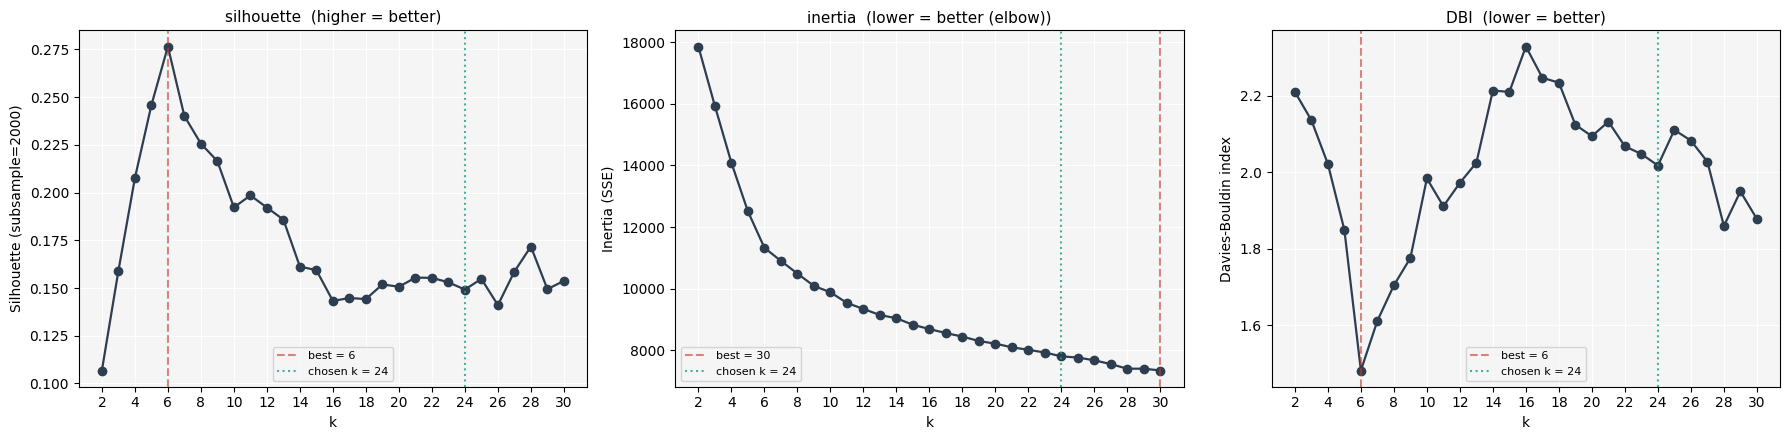


Candidate k per criterion:
  silhouette (max)          -> k = 6
  inertia elbow (max Δ²)    -> k = 7
  DBI (min)                 -> k = 6
  chosen (N_CLIENTS)         -> k = 24


In [27]:
FEATURE_SPECS_SWEEP = [
    ('design_name',      'nominal',  2.00),
    ('size_class',       'ordinal',  1.00),
    ('log_frequency',    'interval', 1.50),
    ('utilization',      'interval', 1.50),
    ('aspect_ratio',     'interval', 1.00),
    ('power_mesh',       'nominal',  0.75),
    ('macro_placement',  'nominal',  0.75),
    ('filler',           'nominal',  0.50),
]
ORDINAL_ORDERS_SWEEP = {'size_class': ['small', 'medium', 'large']}

# Encode once, sweep k with plain sklearn.KMeans on the encoded matrix.
encoder = KPrototypesPartitioner(
    n_partitions=2,  # placeholder; encode() doesn't cluster
    feature_specs=FEATURE_SPECS_SWEEP,
    ordinal_orders=ORDINAL_ORDERS_SWEEP,
    seed=SEED,
)
X = encoder.encode(df_meta)
print(f'Encoded matrix shape: {X.shape}')
print(f'Dropped features (missing / constant on N28): {encoder.dropped_features_}')

K_VALUES = list(range(2, 31))

records = []
labels_by_k = {}
for k in K_VALUES:
    km = KMeans(n_clusters=k, n_init=20, max_iter=300, random_state=SEED)
    lbl = km.fit_predict(X)
    labels_by_k[k] = lbl
    rng = np.random.default_rng(SEED)
    idx = rng.choice(len(X), size=min(SILHOUETTE_SAMPLE_SIZE, len(X)), replace=False)
    sil = float(silhouette_score(X[idx], lbl[idx]))
    dbi = float(davies_bouldin_score(X, lbl))
    records.append({'k': k, 'silhouette': sil, 'inertia': float(km.inertia_), 'DBI': dbi})

sweep = pd.DataFrame(records).set_index('k')
print(sweep.round(4).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, metric, ylabel, better in [
    (axes[0], 'silhouette', 'Silhouette (subsample=2000)',  'higher = better'),
    (axes[1], 'inertia',    'Inertia (SSE)',                'lower = better (elbow)'),
    (axes[2], 'DBI',        'Davies-Bouldin index',         'lower = better'),
]:
    ax.plot(sweep.index, sweep[metric], marker='o', color='#2c3e50', linewidth=1.6)
    ax.set_xlabel('k')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{metric}  ({better})')
    ax.set_xticks(sweep.index[::2])
    if metric == 'silhouette':
        best = sweep[metric].idxmax()
    else:
        best = sweep[metric].idxmin()
    ax.axvline(best, linestyle='--', color='#c0392b', alpha=0.6, label=f'best = {best}')
    ax.axvline(N_CLIENTS, linestyle=':', color='#16a085', alpha=0.8,
               label=f'chosen k = {N_CLIENTS}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

vote = {
    'silhouette (max)':       int(sweep['silhouette'].idxmax()),
    'inertia elbow (max Δ²)': int((sweep['inertia'].diff().diff().abs()).idxmax()),
    'DBI (min)':              int(sweep['DBI'].idxmin()),
}
print('\nCandidate k per criterion:')
for name, k in vote.items():
    print(f'  {name:25s} -> k = {k}')
print(f'  chosen (N_CLIENTS)         -> k = {N_CLIENTS}')

# P3c — k-prototypes at k = 24

Same weight schema as `partitioning_analysis.ipynb`:
`design_name` (2.0), `size_class` (1.0), `log_frequency` (1.5),
`utilization` (1.5), `aspect_ratio` (1.0), `power_mesh` (0.75),
`macro_placement` (0.75), `filler` (0.5). `size_class` and `aspect_ratio`
are constant on N28 and dropped automatically.

At k=24, k-means has enough room to spend one cluster on every plausible
(design × clock-tier × util-tier) cell. Whether it does so — vs. e.g.
carving out something driven by the low-weight flow attributes — is what
the alignment check in the next section measures.

Dropped features (missing/constant): [('size_class', 'constant'), ('aspect_ratio', 'constant')]
Encoded matrix shape: (10242, 22)
k-means inertia: 11328.68

=== P3c K-prototypes (k=6) ===
  clients            : 6
  size min/median/max: 1122 / 1913 / 2042
  size imbalance     : max/min = 1.82x
  mean JS(design_name         ) = 0.658
  mean JS(clock_ns            ) = 0.010
  mean JS(utilization         ) = 0.002
  mean JS(macro_placement     ) = 0.021
  mean JS(power_mesh          ) = 0.000
  mean JS(filler_insertion    ) = 0.006


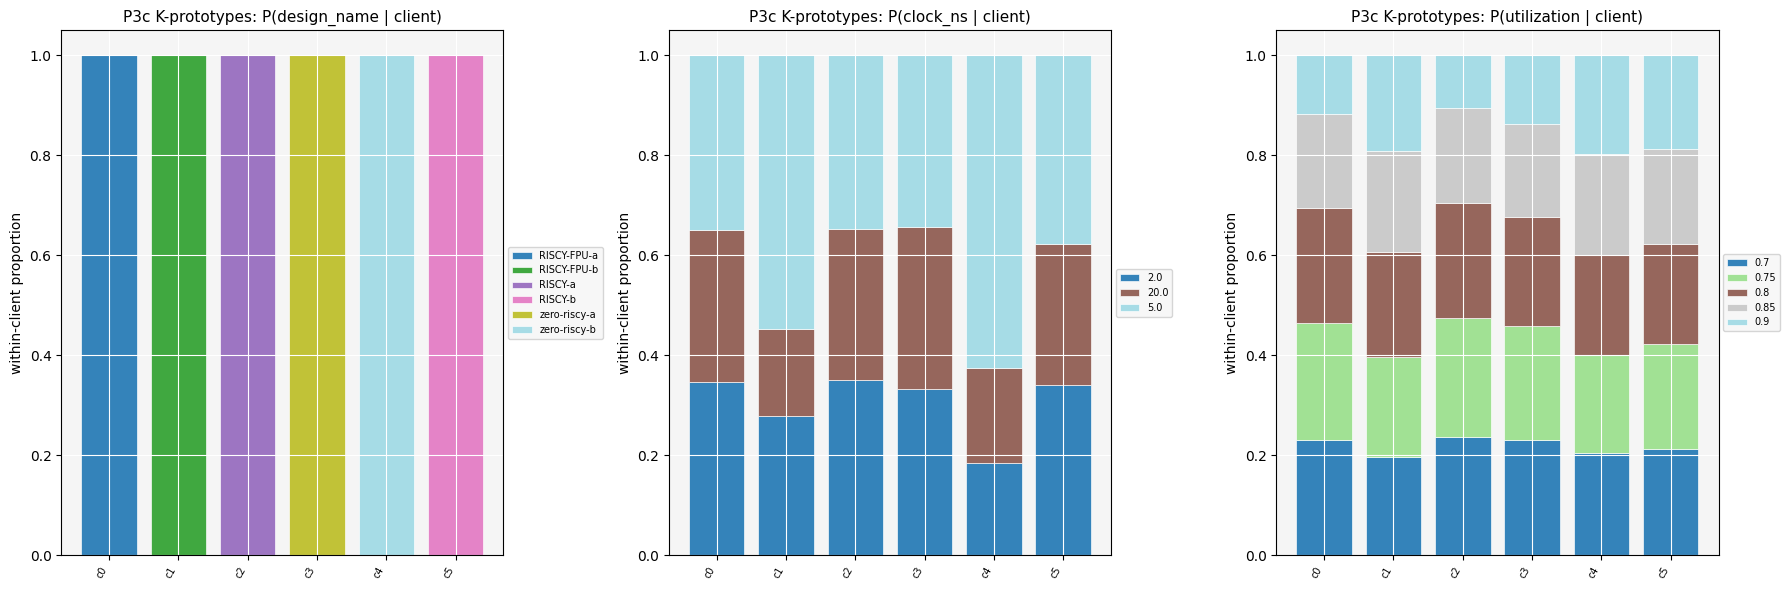

In [28]:
N_CLIENTS = 6
FEATURE_SPECS = [
    ('design_name',      'nominal',  2.00),
    ('size_class',       'ordinal',  1.00),
    ('log_frequency',    'interval', 1.50),
    ('utilization',      'interval', 1.50),
    ('aspect_ratio',     'interval', 1.00),
    ('power_mesh',       'nominal',  0.75),
    ('macro_placement',  'nominal',  0.75),
    ('filler',           'nominal',  0.50),
]
ORDINAL_ORDERS = {'size_class': ['small', 'medium', 'large']}

p3c_part = KPrototypesPartitioner(
    n_partitions=N_CLIENTS,
    feature_specs=FEATURE_SPECS,
    ordinal_orders=ORDINAL_ORDERS,
    seed=SEED,
    n_init=20,
)
p3c = p3c_part.partition(df_meta)

print(f'Dropped features (missing/constant): {p3c_part.dropped_features_}')
print(f'Encoded matrix shape: {p3c_part.encoded_matrix_.shape}')
print(f'k-means inertia: {p3c_part.kmeans_.inertia_:.2f}')

results['P3c_kproto24'] = summarize(p3c, f'P3c K-prototypes (k={N_CLIENTS})')
plot_partition_composition(p3c, 'P3c K-prototypes',
                           cols=('design_name','clock_ns','utilization'))

# Cluster sizes at chosen k

Bar chart of the P3c cluster sizes. At k=24 some cluster imbalance is expected:
in the deterministic 3-axis grid a few (design × clock × util) cells are more
sparsely populated than others (e.g. rare clock/util combinations), and
k-means will roughly mirror that.

We reuse the labels from the k-sweep (`labels_by_k[N_CLIENTS]`); those are
byte-identical to `p3c_part.cluster_labels_` because both fits use the same
encoded matrix, `n_init=20`, and `random_state=SEED`.

Cluster sizes at k=6:
0    1969
1    1248
2    2003
3    2042
4    1122
5    1858
  imbalance max/min = 1.82x


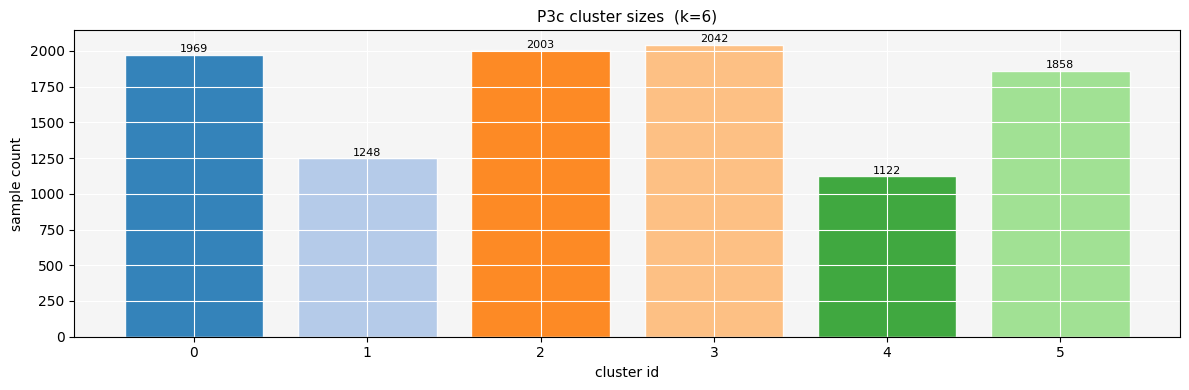

In [29]:
labels = labels_by_k[N_CLIENTS]
df_meta['cluster'] = labels

sizes = pd.Series(labels).value_counts().sort_index()
print(f'Cluster sizes at k={N_CLIENTS}:')
print(sizes.to_string())
print(f'  imbalance max/min = {sizes.max()/max(sizes.min(),1):.2f}x')

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(sizes.index, sizes.values,
       color=mcm.get_cmap('tab20')(np.arange(len(sizes)) % 20),
       alpha=0.9, edgecolor='white')
for i, v in enumerate(sizes.values):
    ax.text(sizes.index[i], v + 20, str(v), ha='center', fontsize=8)
ax.set_xlabel('cluster id')
ax.set_ylabel('sample count')
ax.set_title(f'P3c cluster sizes  (k={N_CLIENTS})')
plt.tight_layout()
plt.show()

# Design-purity check (Cramér's V)

Same rule as in `kprototypes_analysis.ipynb`: with `design_name` weighted at
2.0 the natural failure mode is that clusters end up as a design partition
in disguise. Reported:

- Bias-corrected Cramér's V for (cluster × `design_name`). Bands:
  - **V ≥ 0.90** → clusters are effectively a design partition. Either
    accept and say so, or lower the `design_name` weight (next section).
  - **V ∈ [0.60, 0.90]** → design dominates but non-design knobs still shape
    boundaries.
  - **V < 0.60** → design contributes but doesn't monopolize.
- Row-normalized `P(design_name | cluster)` heatmap — block-diagonal
  (after reordering) is the visual analogue of high V.

We also compute V against binned `clock_ns` and `utilization` so the two
persona sub-axes get the same scrutiny; if utilization is barely picked up
by the clustering, that's evidence the extra axis in P1c is over-fitting
the client count relative to what the data supports.

Cramer's V (cluster x design_name)    = 1.000
Cramer's V (cluster x log_freq_bin)   = 0.108
Cramer's V (cluster x util_bin)       = 0.083
Interpretation (design): DEGENERATE (design-based split with extra steps)

Dominant design per cluster:
         size      dominant  dominant_share
cluster                                    
0        1969   RISCY-FPU-a             1.0
1        1248   RISCY-FPU-b             1.0
2        2003       RISCY-a             1.0
3        2042  zero-riscy-a             1.0
4        1122  zero-riscy-b             1.0
5        1858       RISCY-b             1.0


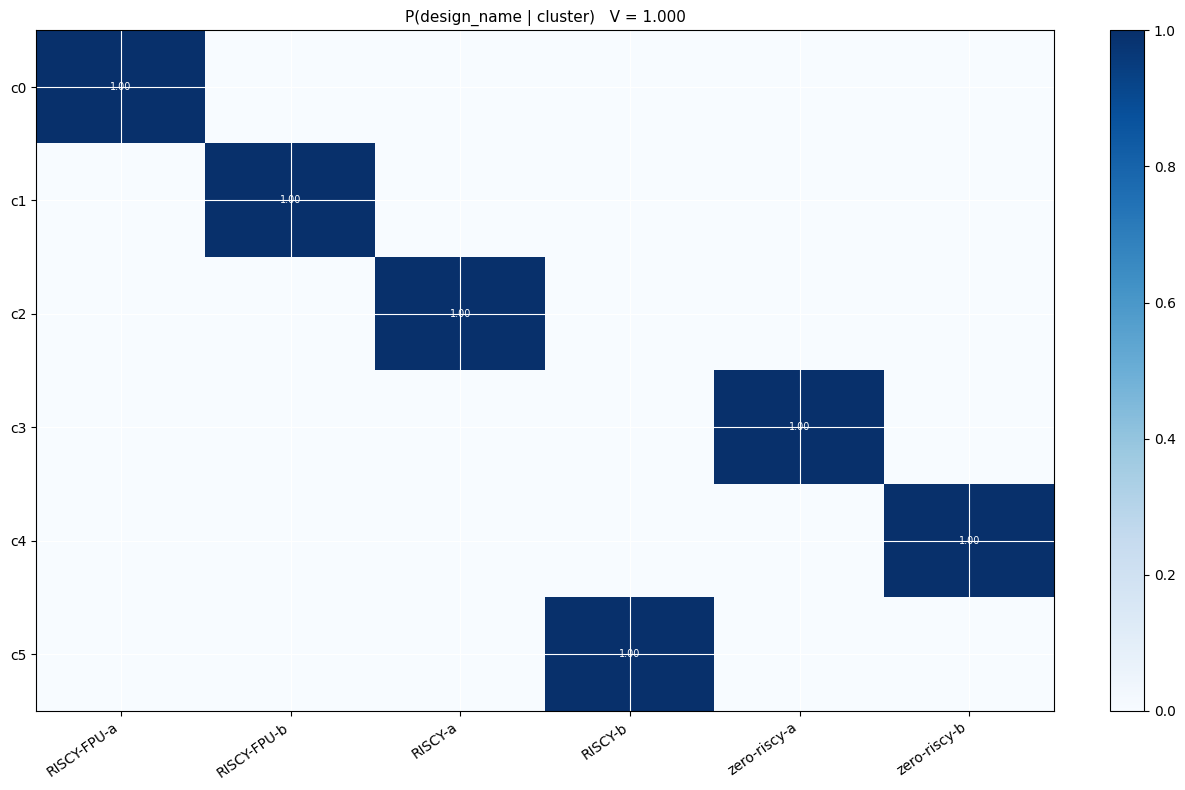

In [30]:
from scipy import stats as scipy_stats


def cramers_v(x, y, bias_correction=True):
    ct = pd.crosstab(x, y)
    chi2, _, _, _ = scipy_stats.chi2_contingency(ct)
    n = ct.values.sum()
    r, k = ct.shape
    if min(r, k) < 2 or n == 0:
        return float('nan')
    if not bias_correction:
        return float(np.sqrt(chi2 / (n * (min(r, k) - 1))))
    phi2 = chi2 / n
    phi2_corr = max(0.0, phi2 - ((r - 1) * (k - 1)) / (n - 1))
    r_c = r - ((r - 1) ** 2) / (n - 1)
    k_c = k - ((k - 1) ** 2) / (n - 1)
    denom = min(k_c - 1, r_c - 1)
    if denom <= 0:
        return 0.0
    return float(np.sqrt(phi2_corr / denom))


def dominant_level_share(df, cluster_col, target_col):
    rows = []
    for c, group in df.groupby(cluster_col):
        vc = group[target_col].value_counts(normalize=True)
        rows.append({
            'cluster':          c,
            'size':             len(group),
            'dominant':         vc.index[0],
            'dominant_share':   round(float(vc.iloc[0]), 3),
        })
    return pd.DataFrame(rows).set_index('cluster')


v_design = cramers_v(df_meta['cluster'], df_meta['design_name'])
freq_bins = pd.qcut(df_meta['log_frequency'], q=N_CLOCK_BINS, duplicates='drop').astype(str)
util_bins = pd.qcut(df_meta['utilization'],   q=N_UTIL_BINS,  duplicates='drop').astype(str)
v_freq = cramers_v(pd.Series(df_meta['cluster']), freq_bins)
v_util = cramers_v(pd.Series(df_meta['cluster']), util_bins)

print(f"Cramer's V (cluster x design_name)    = {v_design:.3f}")
print(f"Cramer's V (cluster x log_freq_bin)   = {v_freq:.3f}")
print(f"Cramer's V (cluster x util_bin)       = {v_util:.3f}")

def _interp(v):
    if v >= 0.90: return 'DEGENERATE (design-based split with extra steps)'
    if v >= 0.60: return 'design-dominated but non-design knobs still shape boundaries'
    return 'design contributes but is not monopolizing'
print('Interpretation (design):', _interp(v_design))

print('\nDominant design per cluster:')
print(dominant_level_share(df_meta, 'cluster', 'design_name').to_string())

fig, ax = plt.subplots(figsize=(12, 8))
ct = pd.crosstab(df_meta['cluster'], df_meta['design_name'])
row_norm = ct.div(ct.sum(axis=1), axis=0)
im = ax.imshow(row_norm.values, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax.set_yticks(range(len(row_norm.index)))
ax.set_yticklabels([f'c{c}' for c in row_norm.index])
ax.set_xticks(range(len(row_norm.columns)))
ax.set_xticklabels(row_norm.columns, rotation=35, ha='right')
for i in range(row_norm.shape[0]):
    for j in range(row_norm.shape[1]):
        v = row_norm.values[i, j]
        if v >= 0.05:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    color='white' if v > 0.55 else 'black', fontsize=7)
ax.set_title(f'P(design_name | cluster)   V = {v_design:.3f}')
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout()
plt.show()

# Weight sensitivity: lower `design_name` from 2.0 → 1.0 → 0.5

If the purity check flagged degeneracy (V > 0.90 on design_name), this
section shows what happens as the design weight drops. Every other weight
is held at the user-supplied value; only `design_name`'s weight changes.

Reported per weight setting:

- V(cluster, design_name) → drops as the design weight drops
- V(cluster, log_freq_bin) and V(cluster, util_bin) → typically rise, since
  the persona knobs get more room to influence the boundary
- Silhouette on the new encoded matrix — the clustering may become less
  crisp when the strongest signal is de-emphasized (the price of forcing
  physical-knob influence)

               V(cluster,design)  V(cluster,log_freq_bin)  V(cluster,util_bin)  silhouette   inertia
design_weight                                                                                       
2.0                        1.000                    0.108                0.083       0.276  11328.68
1.0                        0.144                    0.420                0.457       0.102  11280.29
0.5                        0.084                    0.422                0.394       0.122   9170.59


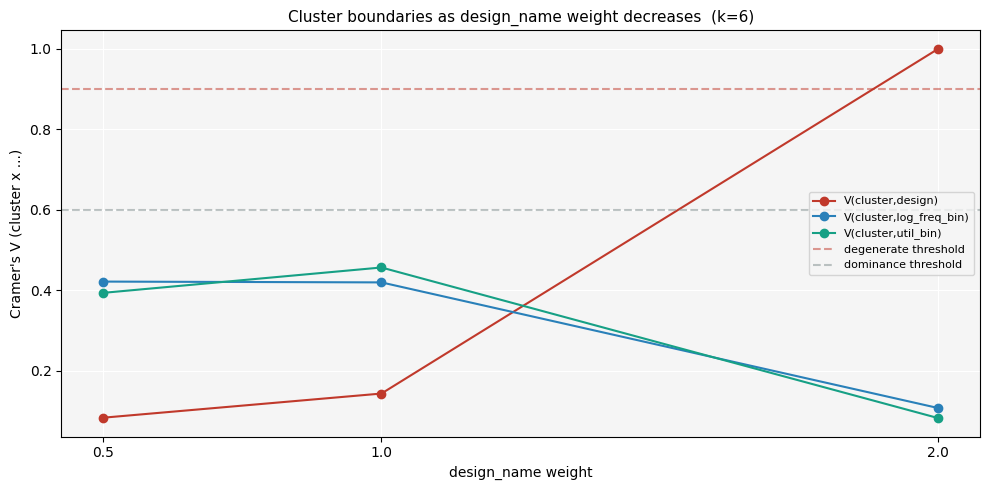

In [31]:
DESIGN_WEIGHTS = [2.00, 1.00, 0.50]

def specs_with_design_weight(w):
    return [(c, kind, wt if c != 'design_name' else w) for c, kind, wt in FEATURE_SPECS_SWEEP]

sweep_rows = []
labels_by_w = {}
for w in DESIGN_WEIGHTS:
    enc = KPrototypesPartitioner(
        n_partitions=2,
        feature_specs=specs_with_design_weight(w),
        ordinal_orders=ORDINAL_ORDERS_SWEEP,
        seed=SEED,
    )
    X_w = enc.encode(df_meta)
    km = KMeans(n_clusters=N_CLIENTS, n_init=20, max_iter=300, random_state=SEED)
    lbl = km.fit_predict(X_w)
    labels_by_w[w] = lbl
    rng = np.random.default_rng(SEED)
    idx = rng.choice(len(X_w), size=min(SILHOUETTE_SAMPLE_SIZE, len(X_w)), replace=False)
    sil = float(silhouette_score(X_w[idx], lbl[idx]))
    v_des_w  = cramers_v(pd.Series(lbl), df_meta['design_name'])
    v_freq_w = cramers_v(pd.Series(lbl), freq_bins)
    v_util_w = cramers_v(pd.Series(lbl), util_bins)
    sweep_rows.append({
        'design_weight':           w,
        "V(cluster,design)":       round(v_des_w, 3),
        "V(cluster,log_freq_bin)": round(v_freq_w, 3),
        "V(cluster,util_bin)":     round(v_util_w, 3),
        'silhouette':              round(sil, 3),
        'inertia':                 round(float(km.inertia_), 2),
    })

sweep_df = pd.DataFrame(sweep_rows).set_index('design_weight')
print(sweep_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
for col, color in [
    ("V(cluster,design)",       '#c0392b'),
    ("V(cluster,log_freq_bin)", '#2980b9'),
    ("V(cluster,util_bin)",     '#16a085'),
]:
    ax.plot(sweep_df.index, sweep_df[col], marker='o', label=col, color=color)
ax.set_xlabel('design_name weight')
ax.set_ylabel("Cramer's V (cluster x ...)")
ax.set_title(f'Cluster boundaries as design_name weight decreases  (k={N_CLIENTS})')
ax.set_xticks(DESIGN_WEIGHTS)
ax.axhline(0.90, color='#c0392b', linestyle='--', alpha=0.5, label='degenerate threshold')
ax.axhline(0.60, color='#7f8c8d', linestyle='--', alpha=0.5, label='dominance threshold')
ax.legend(fontsize=8, loc='center right')
plt.tight_layout()
plt.show()

# Feature importance for the chosen clustering

Which knobs drive the k=24 boundary at the primary weight setting?

- Numeric features (`log_frequency`, `utilization`) → η² (fraction of variance
  in the feature explained by the cluster label).
- Categorical / ordinal features (`design_name`, `size_class`, `power_mesh`,
  `macro_placement`, `filler`) → bias-corrected Cramér's V vs cluster.

Both metrics live on [0, 1] so they rank side-by-side; note they aren't
directly comparable in magnitude across types, so use them to spot the top
axes rather than to make fine distinctions.

        feature     kind  weight   metric  assoc
    design_name  nominal    2.00 Cramer V  1.000
         filler  nominal    0.50 Cramer V  0.152
macro_placement  nominal    0.75 Cramer V  0.132
    utilization interval    1.50    eta^2  0.008
  log_frequency interval    1.50    eta^2  0.002
     power_mesh  nominal    0.75 Cramer V  0.000


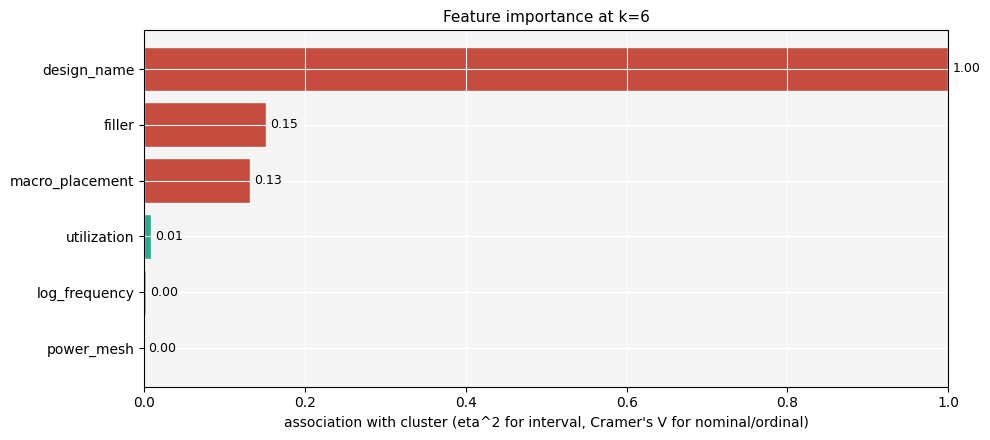


Top-3 features (used for visualization): ['design_name', 'filler', 'macro_placement']


In [32]:
def eta_squared(cat_series, num_series):
    d = pd.DataFrame({'cat': cat_series.values,
                      'num': pd.to_numeric(num_series, errors='coerce').values}).dropna()
    grand = d['num'].mean()
    ss_tot = ((d['num'] - grand) ** 2).sum()
    if ss_tot == 0:
        return float('nan')
    ss_bet = sum(len(g) * (g['num'].mean() - grand) ** 2 for _, g in d.groupby('cat'))
    return float(ss_bet / ss_tot)


dropped_names = {name for name, _ in encoder.dropped_features_}
RETAINED_SPECS = [s for s in FEATURE_SPECS_SWEEP if s[0] not in dropped_names]

clu = pd.Series(labels, name='cluster')

rows = []
for col, kind, w in RETAINED_SPECS:
    if kind == 'interval':
        assoc = eta_squared(clu, df_meta[col])
        metric = 'eta^2'
    else:
        assoc = cramers_v(clu, df_meta[col])
        metric = 'Cramer V'
    rows.append({'feature': col, 'kind': kind, 'weight': w,
                 'metric': metric, 'assoc': round(assoc, 3)})
imp = pd.DataFrame(rows).sort_values('assoc', ascending=False).reset_index(drop=True)
print(imp.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ['#c0392b' if k == 'nominal' else
          '#16a085' if k == 'interval' else
          '#8e44ad' for k in imp['kind']]
ax.barh(imp['feature'], imp['assoc'], color=colors, alpha=0.9, edgecolor='white')
ax.invert_yaxis()
for i, v in enumerate(imp['assoc']):
    ax.text(v + 0.005, i, f'{v:.2f}', va='center', fontsize=9)
ax.set_xlim(0, 1)
ax.set_xlabel("association with cluster (eta^2 for interval, Cramer's V for nominal/ordinal)")
ax.set_title(f'Feature importance at k={N_CLIENTS}')
plt.tight_layout()
plt.show()

TOP_FEATURES = imp['feature'].tolist()[:3]
print(f'\nTop-3 features (used for visualization): {TOP_FEATURES}')

# Cluster visualization

Three views:

1. **Top-2 informative-feature scatter** with jitter (the two features at
   the top of the feature-importance ranking). Colored by cluster; marker
   shape by `design_name`. Small jitter is added on discrete axes so
   overplotted points remain readable.
2. **Three pairwise scatter plots** across the top-3 features (2D
   projections of the informative subspace).
3. **PCA(2)** of the full weighted-encoded space, colored by cluster and,
   separately, by `design_name`. Shows how much of the design axis the two
   principal directions capture."

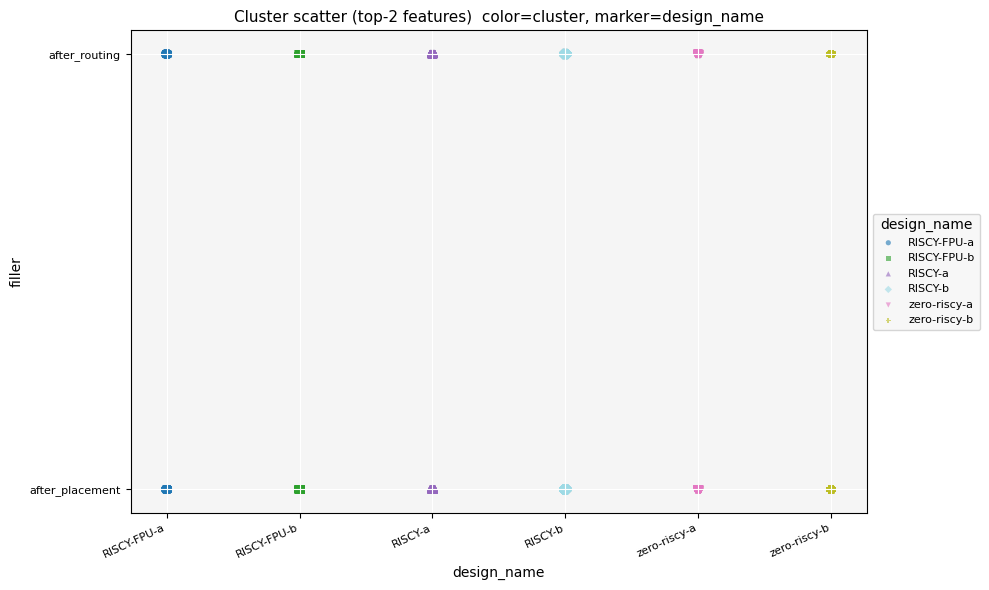

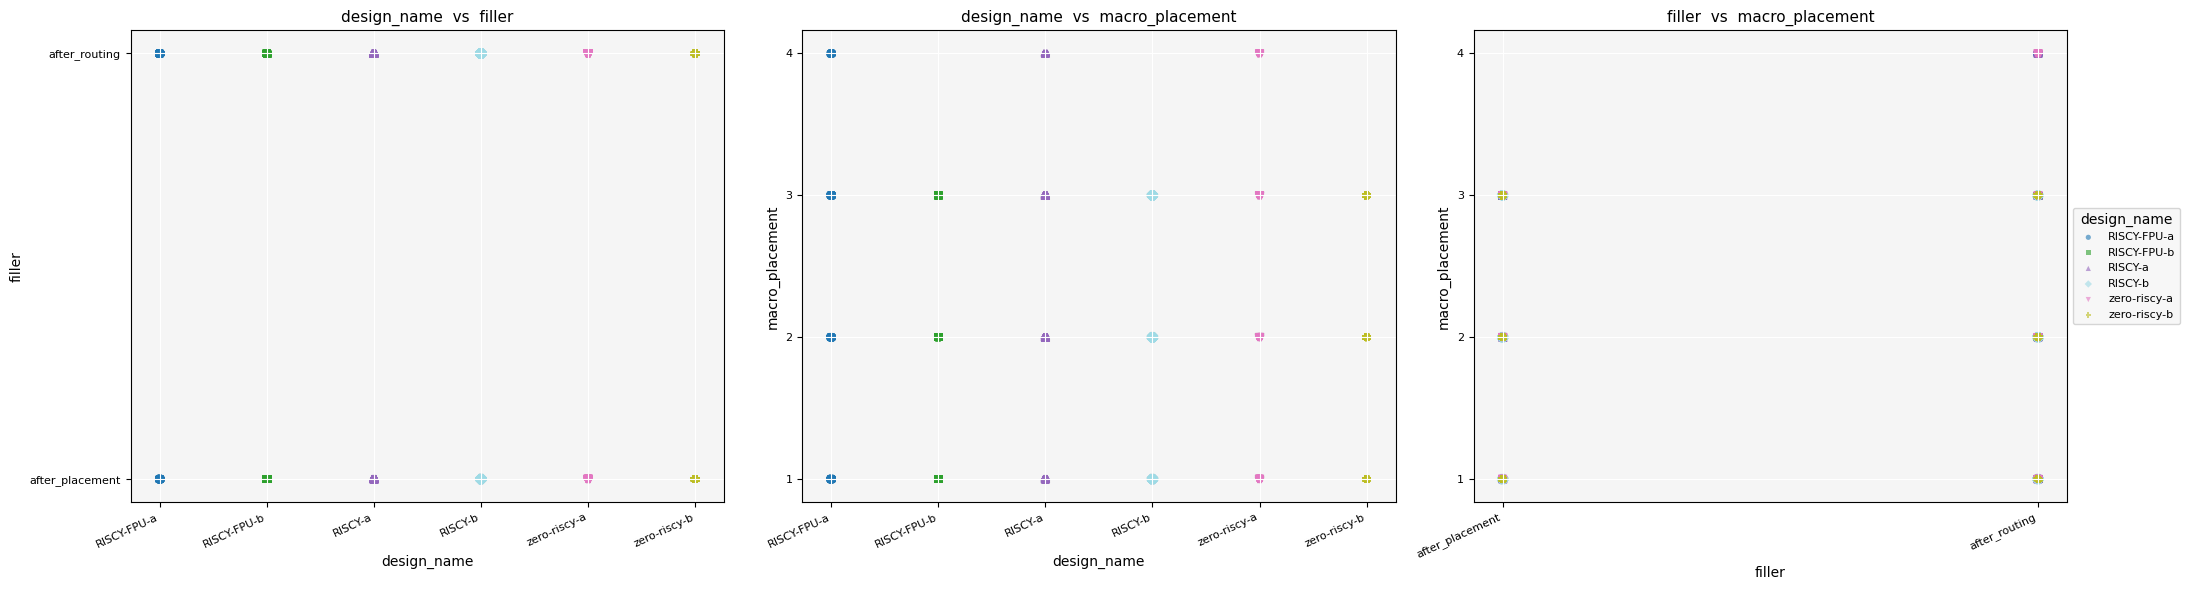

PCA explained variance: [0.116, 0.103] (total 0.219)


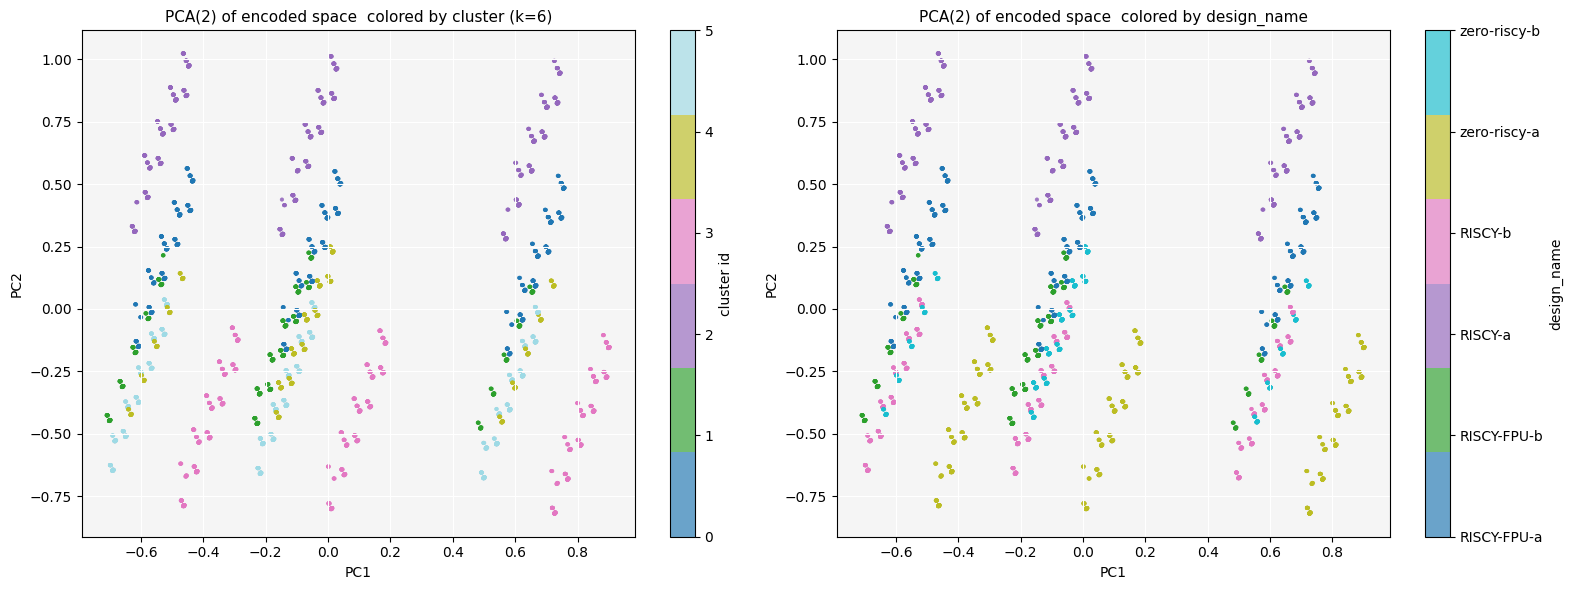

In [33]:
from sklearn.decomposition import PCA


def _to_numeric(series):
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(float).to_numpy(), None
    levels = sorted(series.astype(str).unique().tolist())
    code_map = {lvl: i for i, lvl in enumerate(levels)}
    return series.astype(str).map(code_map).to_numpy(dtype=float), levels


def _axis_values(df, col):
    return _to_numeric(df[col])


def _jitter(values, scale=0.08, seed=SEED):
    rng = np.random.default_rng(seed)
    span = np.ptp(values) if np.ptp(values) > 0 else 1.0
    return values + rng.uniform(-scale, scale, size=len(values)) * span * 0.05


def scatter_cluster(ax, df, xcol, ycol, labels, group_col='design_name'):
    xv, xlvls = _axis_values(df, xcol)
    yv, ylvls = _axis_values(df, ycol)
    xv, yv = _jitter(xv, seed=SEED), _jitter(yv, seed=SEED + 1)
    cmap = mcm.get_cmap('tab20', max(int(labels.max()) + 1, 3))
    groups = sorted(df[group_col].astype(str).unique().tolist())
    markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h', '<', '>', 'p']
    for gi, g in enumerate(groups):
        m = (df[group_col].astype(str) == g).to_numpy()
        if not m.any():
            continue
        ax.scatter(xv[m], yv[m], c=labels[m], cmap=cmap,
                   marker=markers[gi % len(markers)], s=14, alpha=0.6,
                   edgecolor='none', label=g,
                   vmin=0, vmax=max(int(labels.max()), 1))
    ax.set_xlabel(xcol); ax.set_ylabel(ycol)
    if xlvls is not None:
        ax.set_xticks(range(len(xlvls))); ax.set_xticklabels(xlvls, rotation=25, ha='right', fontsize=8)
    if ylvls is not None:
        ax.set_yticks(range(len(ylvls))); ax.set_yticklabels(ylvls, fontsize=8)


# View 1: top-2 pairwise scatter
top2 = TOP_FEATURES[:2]
fig, ax = plt.subplots(figsize=(10, 6))
scatter_cluster(ax, df_meta, top2[0], top2[1], labels)
ax.set_title('Cluster scatter (top-2 features)  color=cluster, marker=design_name')
ax.legend(fontsize=8, loc='center left', bbox_to_anchor=(1.0, 0.5), title='design_name')
plt.tight_layout()
plt.show()

# View 2: three pairwise scatters (top-3)
if len(TOP_FEATURES) >= 3:
    pairs = [(TOP_FEATURES[0], TOP_FEATURES[1]),
             (TOP_FEATURES[0], TOP_FEATURES[2]),
             (TOP_FEATURES[1], TOP_FEATURES[2])]
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    for ax, (xc, yc) in zip(axes, pairs):
        scatter_cluster(ax, df_meta, xc, yc, labels)
        ax.set_title(f'{xc}  vs  {yc}')
    axes[-1].legend(fontsize=8, loc='center left', bbox_to_anchor=(1.0, 0.5), title='design_name')
    plt.tight_layout()
    plt.show()

# View 3: PCA(2) on encoded space
pca = PCA(n_components=2, random_state=SEED)
Z = pca.fit_transform(X)
print(f'PCA explained variance: {pca.explained_variance_ratio_.round(3).tolist()} '
      f'(total {pca.explained_variance_ratio_.sum():.3f})')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cmap_c = mcm.get_cmap('tab20', max(int(labels.max()) + 1, 3))
sc1 = axes[0].scatter(Z[:, 0], Z[:, 1], c=labels, cmap=cmap_c, s=8, alpha=0.65,
                       edgecolor='none', vmin=0, vmax=max(int(labels.max()), 1))
axes[0].set_title(f'PCA(2) of encoded space  colored by cluster (k={N_CLIENTS})')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(sc1, ax=axes[0], label='cluster id')

designs = sorted(df_meta['design_name'].astype(str).unique().tolist())
des_codes = df_meta['design_name'].astype(str).map({d: i for i, d in enumerate(designs)}).to_numpy()
cmap_d = mcm.get_cmap('tab10', max(len(designs), 3))
sc2 = axes[1].scatter(Z[:, 0], Z[:, 1], c=des_codes, cmap=cmap_d, s=8, alpha=0.65,
                       edgecolor='none', vmin=0, vmax=max(len(designs) - 1, 1))
axes[1].set_title('PCA(2) of encoded space  colored by design_name')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
cbar = plt.colorbar(sc2, ax=axes[1], ticks=range(len(designs)))
cbar.set_ticklabels(designs)
cbar.set_label('design_name')

plt.tight_layout()
plt.show()

# Cluster profile table

For quick prose in the thesis: per cluster, the modal category (with share)
of every nominal/ordinal feature and the mean of every numeric feature.

In [34]:
profile_rows = []
for c, group in df_meta.groupby('cluster'):
    row = {'cluster': int(c), 'size': len(group)}
    for col, kind, _ in RETAINED_SPECS:
        if kind == 'interval':
            row[col] = round(float(group[col].mean()), 3)
        else:
            vc = group[col].astype(str).value_counts(normalize=True)
            row[col] = f'{vc.index[0]} ({vc.iloc[0]:.0%})'
    profile_rows.append(row)
profile_df = pd.DataFrame(profile_rows).set_index('cluster')
print(profile_df.to_string())

         size          design_name  log_frequency  utilization power_mesh macro_placement                 filler
cluster                                                                                                         
0        1969   RISCY-FPU-a (100%)          2.256        0.786    3 (13%)         1 (31%)  after_placement (52%)
1        1248   RISCY-FPU-b (100%)          2.307        0.800    5 (13%)         1 (38%)  after_placement (72%)
2        2003       RISCY-a (100%)          2.259        0.784    6 (13%)         1 (31%)  after_placement (52%)
3        2042  zero-riscy-a (100%)          2.239        0.789    6 (13%)         1 (31%)  after_placement (53%)
4        1122  zero-riscy-b (100%)          2.260        0.800    3 (13%)         1 (35%)  after_placement (69%)
5        1858       RISCY-b (100%)          2.266        0.797    5 (13%)         1 (37%)  after_placement (55%)


# P1c ↔ P3c alignment (3-axis persona validation)

Same test as in the main partitioning notebook, but on the 3-axis grid.
If ARI/NMI are noticeably higher here than in the 2-axis comparison, adding
the utilization split into the hand-drawn personas is a good match for what
the data-driven clustering was already doing implicitly. If they're the same
or worse, utilization isn't providing enough independent separation to
justify the extra client count.

ARI(P1c, P3c) = 0.449
NMI(P1c, P3c) = 0.744

P3c (cluster)                          0    1    2    3    4    5
P1c (design|clock|util)                                          
RISCY-FPU-a|clock_ns0|utilization0   936    0    0    0    0    0
RISCY-FPU-a|clock_ns0|utilization1   434    0    0    0    0    0
RISCY-FPU-a|clock_ns1|utilization0   431    0    0    0    0    0
RISCY-FPU-a|clock_ns1|utilization1   168    0    0    0    0    0
RISCY-FPU-b|clock_ns0|utilization0     0  604    0    0    0    0
RISCY-FPU-b|clock_ns0|utilization1     0  426    0    0    0    0
RISCY-FPU-b|clock_ns1|utilization0     0  152    0    0    0    0
RISCY-FPU-b|clock_ns1|utilization1     0   66    0    0    0    0
RISCY-a|clock_ns0|utilization0         0    0  981    0    0    0
RISCY-a|clock_ns0|utilization1         0    0  417    0    0    0
RISCY-a|clock_ns1|utilization0         0    0  430    0    0    0
RISCY-a|clock_ns1|utilization1         0    0  175    0    0    0
RISCY-b|clock_ns0|utilization0 

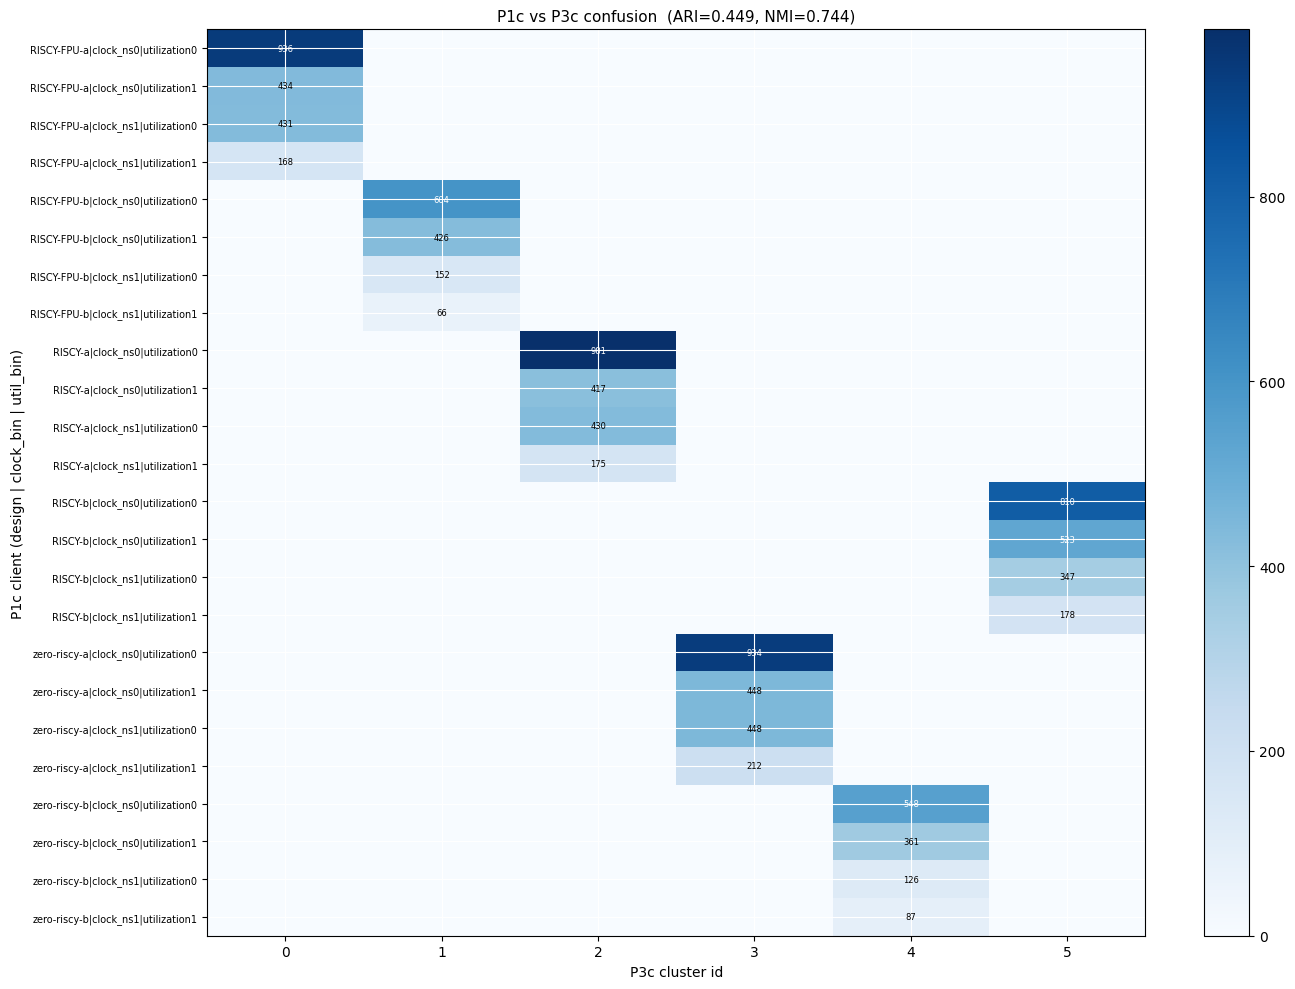

In [35]:
labels_p1c, labels_p3c = align_labels(p1c, p3c, key='filename')
ari = adjusted_rand_score(labels_p1c, labels_p3c)
nmi = normalized_mutual_info_score(labels_p1c, labels_p3c)
print(f'ARI(P1c, P3c) = {ari:.3f}')
print(f'NMI(P1c, P3c) = {nmi:.3f}')

cell_names = [p1c[i]['_client_cell'].iloc[0] for i in range(len(p1c))]
cm = pd.crosstab(
    pd.Series(labels_p1c, name='P1c (design|clock|util)').map(dict(enumerate(cell_names))),
    pd.Series(labels_p3c, name='P3c (cluster)'),
)
print()
print(cm)

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(cm.values, cmap='Blues', aspect='auto')
ax.set_xlabel('P3c cluster id')
ax.set_ylabel('P1c client (design | clock_bin | util_bin)')
ax.set_xticks(range(cm.shape[1]))
ax.set_xticklabels(cm.columns)
ax.set_yticks(range(cm.shape[0]))
ax.set_yticklabels(cm.index, fontsize=7)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        v = cm.values[i, j]
        if v > 0:
            ax.text(j, i, str(v), ha='center', va='center', fontsize=6,
                    color='white' if v > cm.values.max() / 2 else 'black')
ax.set_title(f'P1c vs P3c confusion  (ARI={ari:.3f}, NMI={nmi:.3f})')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Summary

Side-by-side size imbalance and per-factor JS divergence for the two 3-axis
strategies. Interpretation:

- **JS on `design_name` / `clock_ns` / `utilization`** should all be high
  for both strategies — the whole point of the 3-axis grid is to concentrate
  each of them into specific clients.
- **JS on flow columns** (`macro_placement`, `power_mesh`,
  `filler_insertion`) should stay low: neither the hand-drawn cells nor the
  k-prototypes weighting is asking the flow attributes to separate anything.

              n_clients  imbalance  min_size  max_size  JS[design_name]  JS[clock_ns]  JS[utilization]  JS[macro_placement]  JS[power_mesh]  JS[filler_insertion]
strategy                                                                                                                                                         
P1c_hier3            24      14.86        66       981            0.658         0.341            0.324                0.024           0.001                 0.047
P3c_kproto24          6       1.82      1122      2042            0.658         0.010            0.002                0.021           0.000                 0.006


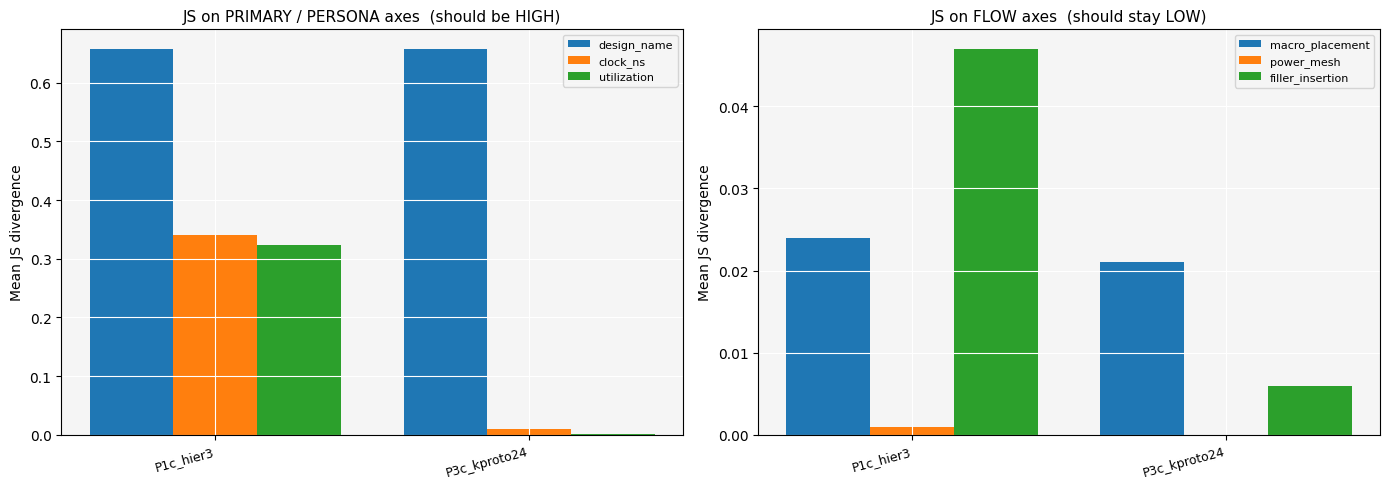

In [36]:
rows = []
for name, res in results.items():
    row = {
        'strategy':   name,
        'n_clients':  len(res['sizes']),
        'imbalance':  round(res['imbalance'], 2),
        'min_size':   min(res['sizes']),
        'max_size':   max(res['sizes']),
    }
    for col in FACTOR_COLS:
        row[f'JS[{col}]'] = round(res['js_mean'][col], 3)
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('strategy')
print(summary_df.to_string())

primary_cols = [c for c in summary_df.columns if c.startswith('JS[') and
                any(k in c for k in ('design_name','clock_ns','utilization'))]
flow_cols    = [c for c in summary_df.columns if c.startswith('JS[') and
                any(k in c for k in ('macro_placement','power_mesh','filler_insertion'))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, group, title in [
    (axes[0], primary_cols, 'JS on PRIMARY / PERSONA axes  (should be HIGH)'),
    (axes[1], flow_cols,    'JS on FLOW axes  (should stay LOW)'),
]:
    sub = summary_df[group]
    x = np.arange(len(sub.index))
    width = 0.8 / max(len(group), 1)
    for j, col in enumerate(group):
        ax.bar(x + j*width, sub[col].values, width=width,
               label=col.replace('JS[','').rstrip(']'))
    ax.set_xticks(x + width * (len(group) - 1) / 2)
    ax.set_xticklabels(sub.index, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('Mean JS divergence')
    ax.set_title(title)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Save partitions

Written to `./partition_outputs/`; one CSV per (strategy, client) listing
the sample filenames that belong to that client.

In [37]:
def save_partitions(parts, prefix):
    for i, p in enumerate(parts):
        p[['filename']].to_csv(
            os.path.join(OUT_DIR, f'{prefix}_client_{i:02d}.csv'), index=False
        )
    print(f'  saved {len(parts)} files: {prefix}_client_*.csv')

save_partitions(p1c,  'P1c_hier3axis')
save_partitions(p3c,  'P3c_kproto24')
print(f'All partitions written to {OUT_DIR}/')

  saved 24 files: P1c_hier3axis_client_*.csv
  saved 6 files: P3c_kproto24_client_*.csv
All partitions written to ./partition_outputs/
